# Занятие 1. Реальный датасет из интернета + ИИ для аналитика данных

## Зачем этот ноутбук

На предыдущем варианте первого занятия мы учились:
- загружать **реальный датасет из интернета**;
- смотреть структуру данных;
- делать простые таблицы, графики и выводы.

Теперь мы делаем следующий шаг:  
**подключаем инструменты ИИ / машинного обучения для аналитики данных**.

В этом ноутбуке мы не просто анализируем данные, а строим простую модель, которая **прогнозирует ожидаемую продолжительность жизни** (`lifeExp`) по признакам:
- `year` — год наблюдения;
- `gdpPercap` — ВВП на душу населения;
- `pop` — численность населения.

---

## Что здесь считается ИИ

В рамках учебного блока под ИИ мы понимаем **машинное обучение**:
- программа получает примеры из данных;
- находит закономерности;
- затем делает прогноз для новых объектов.

Здесь мы используем **регрессию** — метод машинного обучения для предсказания числового значения.

---

## Почему это важно для дипломного проекта

В дипломном проекте вам нужно уметь пройти полный путь:

1. найти открытый датасет по теме проекта;
2. загрузить его из интернета или из файла;
3. изучить его структуру;
4. выбрать целевой показатель для анализа или прогноза;
5. подготовить признаки;
6. обучить простую модель;
7. оценить качество результата;
8. сделать понятные выводы.

---

## Что вы должны понять после этого ноутбука

После выполнения ноутбука вы должны уметь ответить на вопросы:

- какой столбец является **целевой переменной**;
- какие столбцы можно использовать как **признаки**;
- как разделять данные на обучение и проверку;
- как строить простой прогноз;
- как объяснить результат модели обычным человеческим языком.

---

## Датасет

Мы используем открытый датасет Gapminder:
- страны мира;
- годы наблюдений;
- население;
- ВВП на душу населения;
- ожидаемая продолжительность жизни.

## Практическая ячейка 1. Импорт библиотек и загрузка датасета

### Что делает эта ячейка
- подключает библиотеки для анализа данных, визуализации и машинного обучения;
- загружает CSV-файл по URL из интернета;
- сохраняет его в DataFrame `df`;
- показывает первые строки таблицы.

### Краткий алгоритм
1. Импортировать библиотеки.
2. Задать ссылку на датасет.
3. Прочитать CSV-файл через `pd.read_csv(...)`.
4. Сохранить данные в переменную `df`.
5. Посмотреть первые строки.

### Библиотеки и функции ИИ, которые используются

#### `pandas`
Библиотека для табличных данных.
- `pd.read_csv(...)` — загружает CSV в DataFrame.
- `DataFrame` — основная табличная структура данных в Python.

#### `matplotlib.pyplot`
Библиотека для построения графиков.
- `plt.figure(...)` — создаёт область рисунка.
- `plt.scatter(...)` — строит точечный график.
- `plt.plot(...)` — рисует линию.
- `plt.xlabel(...)`, `plt.ylabel(...)`, `plt.title(...)` — подписи и заголовок.

#### `sklearn.model_selection`
Модуль для подготовки эксперимента машинного обучения.
- `train_test_split(...)` — делит данные на обучающую и тестовую части.

#### `sklearn.linear_model`
Модуль с линейными моделями.
- `LinearRegression()` — модель линейной регрессии для прогноза числового значения.

#### `sklearn.metrics`
Модуль оценки качества модели.
- `mean_absolute_error(...)` — средняя абсолютная ошибка.
- `mean_squared_error(...)` — средняя квадратичная ошибка.
- `r2_score(...)` — коэффициент детерминации, показывающий, насколько хорошо модель объясняет разброс целевой переменной.

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# URL открытого датасета
url = "https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv"

fallback_paths = [
    "gapminderDataFiveYear.csv",
    "/mnt/data/gapminderDataFiveYear.csv",
]

try:
    df = pd.read_csv(url)
    print("Данные успешно загружены из интернета.")
except Exception:
    print("Не удалось загрузить данные из интернета. Используется локальная копия.")
    loaded = False
    for path in fallback_paths:
        if os.path.exists(path):
            df = pd.read_csv(path)
            loaded = True
            print(f"Локальная копия загружена из: {path}")
            break
    if not loaded:
        raise FileNotFoundError("Не найден локальный файл gapminderDataFiveYear.csv для резервной загрузки.")

df.head()

Данные успешно загружены из интернета.


,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710
3,Afghanistan,1967,11537966.0,Asia,34.020,836.197138
4,Afghanistan,1972,13079460.0,Asia,36.088,739.981106


## Практическая ячейка 2. Первичный обзор и постановка аналитической задачи

### Что делает эта ячейка
- показывает размер таблицы;
- выводит названия столбцов и типы данных;
- показывает базовую статистику;
- формулирует задачу машинного обучения.

### Краткий алгоритм
1. Посмотреть размер таблицы.
2. Посмотреть названия колонок.
3. Проверить типы данных.
4. Вывести описательную статистику.
5. Выбрать целевую переменную и признаки.

### Важные понятия

#### Целевая переменная (`target`)
Это столбец, который мы хотим прогнозировать.  
В этом ноутбуке цель — прогнозировать `lifeExp`.

#### Признаки (`features`)
Это столбцы, по которым модель будет строить прогноз.  
Мы используем:
- `year`
- `gdpPercap`
- `pop`

#### Почему именно так
Для первого знакомства с ИИ нужно брать:
- понятную цель;
- немного признаков;
- прозрачную интерпретацию результата.

In [ ]:
print("Размер таблицы:", df.shape)
print("\nНазвания столбцов:")
print(df.columns.tolist())

print("\nТипы данных:")
print(df.dtypes)

print("\nОписательная статистика:")
display(df.describe())

target_column = "lifeExp"
feature_columns = ["year", "gdpPercap", "pop"]

print("\nЦелевая переменная:", target_column)
print("Признаки:", feature_columns)

Размер таблицы: (1704, 6)

Названия столбцов:
['country', 'year', 'pop', 'continent', 'lifeExp', 'gdpPercap']

Типы данных:
country       object
year           int64
pop          float64
continent     object
lifeExp      float64
gdpPercap    float64
dtype: object

Описательная статистика:


,year,pop,lifeExp,gdpPercap
count,1704.00000,1.704000e+03,1704.000000,1704.000000
mean,1979.50000,2.960121e+07,59.474439,7215.327081
std,17.26533,1.061579e+08,12.917107,9857.454543
min,1952.00000,6.001100e+04,23.599000,241.165876
25%,1965.75000,2.793664e+06,48.198000,1202.060309
50%,1979.50000,7.023596e+06,60.712500,3531.846988
75%,1993.25000,1.958522e+07,70.845500,9325.462346
max,2007.00000,1.318683e+09,82.603000,113523.132900



Целевая переменная: lifeExp
Признаки: ['year', 'gdpPercap', 'pop']


## Практическая ячейка 3. Подготовка данных для модели ИИ

### Что делает эта ячейка
- выбирает нужные столбцы;
- проверяет пропуски;
- формирует матрицу признаков `X` и целевую переменную `y`;
- делит данные на обучающую и тестовую выборки.

### Краткий алгоритм
1. Взять только нужные колонки.
2. Проверить пропуски.
3. Сформировать `X` и `y`.
4. Разделить данные на train и test.
5. Проверить размеры получившихся выборок.

### Функции и синтаксис ИИ

#### `X = df[feature_columns]`
Берёт из таблицы только столбцы-признаки.

#### `y = df[target_column]`
Берёт целевой столбец.

#### `train_test_split(X, y, test_size=..., random_state=...)`
Делит данные на две части:
- **train** — для обучения модели;
- **test** — для проверки качества на новых данных.

Параметры:
- `test_size=0.2` — 20% данных идёт в тест;
- `random_state=42` — фиксирует случайное разбиение, чтобы результат был воспроизводимым.

In [ ]:
model_df = df[feature_columns + [target_column]].copy()

print("Пропуски по столбцам:")
print(model_df.isna().sum())

X = model_df[feature_columns]
y = model_df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nРазмер X_train:", X_train.shape)
print("Размер X_test:", X_test.shape)
print("Размер y_train:", y_train.shape)
print("Размер y_test:", y_test.shape)

Пропуски по столбцам:
year         0
gdpPercap    0
pop          0
lifeExp      0
dtype: int64

Размер X_train: (1363, 3)
Размер X_test: (341, 3)
Размер y_train: (1363,)
Размер y_test: (341,)


## Практическая ячейка 4. Обучение модели линейной регрессии

### Что делает эта ячейка
- создаёт объект модели;
- обучает модель на обучающей выборке;
- получает коэффициенты модели;
- показывает, как признаки влияют на прогноз.

### Краткий алгоритм
1. Создать объект `LinearRegression()`.
2. Передать в `fit(...)` обучающие данные.
3. Получить коэффициенты и свободный член.
4. Сопоставить коэффициенты с признаками.
5. Сформулировать первичную интерпретацию.

### Функции и синтаксис ИИ

#### `LinearRegression()`
Создаёт модель линейной регрессии.

#### `model.fit(X_train, y_train)`
Обучает модель:
- получает признаки `X_train`;
- получает правильные ответы `y_train`;
- подбирает коэффициенты.

#### `model.coef_`
Массив коэффициентов при признаках.

#### `model.intercept_`
Свободный член линейной модели.

#### Как читать коэффициенты
Знак коэффициента показывает направление связи:
- положительный — при росте признака прогноз обычно увеличивается;
- отрицательный — при росте признака прогноз обычно уменьшается.

Для реальной аналитики коэффициенты нужно интерпретировать осторожно, особенно если признаки имеют разные масштабы.

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

coef_df = pd.DataFrame({
    "feature": feature_columns,
    "coefficient": model.coef_
})

print("Свободный член модели:")
print(model.intercept_)

print("\nКоэффициенты модели:")
display(coef_df)

Свободный член модели:
-435.1029649561423

Коэффициенты модели:


,feature,coefficient
0,year,2.473485e-01
1,gdpPercap,6.318524e-04
2,pop,6.860954e-09


## Практическая ячейка 5. Прогноз и оценка качества модели

### Что делает эта ячейка
- строит прогноз на тестовой выборке;
- считает ошибки модели;
- сравнивает реальные и предсказанные значения;
- визуально показывает качество прогноза.

### Краткий алгоритм
1. Вызвать `predict(...)` для тестовой выборки.
2. Сравнить прогноз с реальными значениями.
3. Посчитать метрики качества.
4. Построить график `факт vs прогноз`.
5. Сделать предварительный вывод о качестве модели.

### Функции и синтаксис ИИ

#### `model.predict(X_test)`
Строит прогноз для новых данных.

#### `mean_absolute_error(y_test, y_pred)`
Показывает среднюю абсолютную ошибку в тех же единицах, что и целевая переменная.

#### `mean_squared_error(y_test, y_pred)`
Считает среднюю квадратичную ошибку.  
Сильнее штрафует крупные ошибки.

#### `r2_score(y_test, y_pred)`
Показывает, какую долю разброса целевой переменной объясняет модель.
- ближе к `1` — лучше;
- около `0` — слабое объяснение;
- ниже `0` — модель работает очень плохо.

### Почему аналитик должен смотреть не на одну метрику
Одна метрика может быть обманчива.  
Поэтому полезно смотреть:
- на абсолютную ошибку;
- на квадратичную ошибку;
- на долю объяснённого разброса (`R²`);
- на график.

MAE: 7.537
MSE: 77.297
RMSE: 8.792
R2: 0.494


,real_lifeExp,predicted_lifeExp
0,45.108,50.602171
1,68.900,52.515653
2,70.110,58.121826
3,54.655,57.815280
4,67.660,60.932044
5,50.254,53.416701
6,50.485,56.931894
7,75.250,71.768177
8,50.725,60.889895
9,70.670,60.150362


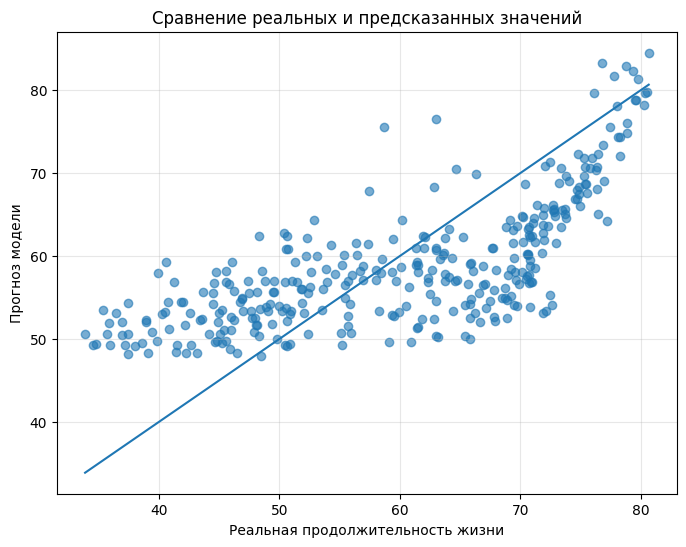

In [ ]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

results_df = pd.DataFrame({
    "real_lifeExp": y_test.values,
    "predicted_lifeExp": y_pred
})

print("MAE:", round(mae, 3))
print("MSE:", round(mse, 3))
print("RMSE:", round(rmse, 3))
print("R2:", round(r2, 3))

display(results_df.head(10))

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Реальная продолжительность жизни")
plt.ylabel("Прогноз модели")
plt.title("Сравнение реальных и предсказанных значений")
plt.grid(alpha=0.3)
plt.show()

## Практическая ячейка 6. Использование модели: прогноз для новых примеров и выводы

### Что делает эта ячейка
- создаёт несколько новых наблюдений;
- строит прогноз по ним;
- показывает, как использовать модель в прикладной аналитике;
- формулирует выводы и мост к дипломному проекту.

### Краткий алгоритм
1. Подготовить таблицу с новыми примерами.
2. Передать её в `model.predict(...)`.
3. Получить прогноз.
4. Сравнить сценарии между собой.
5. Сформулировать выводы для дипломного проекта.

### Почему это важно для диплома
В дипломном проекте студенту нужно не просто «обучить модель», а показать:
- какие данные были выбраны;
- почему именно эти признаки использовались;
- как оценивалось качество;
- как результат можно применить по теме проекта.

In [ ]:
new_cases = pd.DataFrame({
    "year": [2007, 2007, 2007],
    "gdpPercap": [1500, 8000, 25000],
    "pop": [5_000_000, 20_000_000, 50_000_000]
})

new_cases["predicted_lifeExp"] = model.predict(new_cases)

display(new_cases)

assert set(feature_columns) == {"year", "gdpPercap", "pop"}
assert len(y_pred) == len(y_test)
assert "predicted_lifeExp" in new_cases.columns

print("Вывод 1:")
print("Мы показали полный цикл аналитики с ИИ: от загрузки открытого датасета до прогноза числового показателя.")

print("\nВывод 2:")
print("Даже простая модель уже помогает увидеть связь между социально-экономическими признаками и целевой переменной.")

print("\nВывод 3:")
print("Для дипломного проекта важно не только скачать датасет, но и выбрать осмысленную цель анализа или прогноза.")

print("\nЗадание для дипломного проекта:")
print("Найдите датасет по вашей теме, определите целевой столбец, выберите 2–5 признаков и предложите, что именно можно прогнозировать или кластеризовать.")

,year,gdpPercap,pop,predicted_lifeExp
0,2007,1500,5000000,62.307625
1,2007,8000,20000000,66.517580
2,2007,25000,50000000,77.464899


Вывод 1:
Мы показали полный цикл аналитики с ИИ: от загрузки открытого датасета до прогноза числового показателя.

Вывод 2:
Даже простая модель уже помогает увидеть связь между социально-экономическими признаками и целевой переменной.

Вывод 3:
Для дипломного проекта важно не только скачать датасет, но и выбрать осмысленную цель анализа или прогноза.

Задание для дипломного проекта:
Найдите датасет по вашей теме, определите целевой столбец, выберите 2–5 признаков и предложите, что именно можно прогнозировать или кластеризовать.


## Что студент должен вынести из этого занятия

После выполнения ноутбука вы должны понимать:

- реальный датасет можно загружать прямо из интернета;
- ИИ в аналитике данных часто начинается не с «магии», а с простой и понятной модели;
- для прогноза нужно выбрать:
  - целевую переменную;
  - признаки;
  - способ оценки качества;
- результат работы аналитика — это:
  - таблицы,
  - графики,
  - метрики,
  - текстовые выводы.

## Как связать это с дипломом

Для следующего шага подготовьте:

1. тему дипломного проекта;
2. ссылку на 1–3 открытых датасета;
3. предполагаемую цель анализа:
   - прогноз,
   - классификация,
   - кластеризация,
   - поиск закономерностей;
4. список возможных признаков;
5. краткое объяснение, почему эти данные подходят для проекта.